# 00 — REFPROP and SeitzModel validation

This notebook verifies the external thermodynamics stack before any MD data are used.

It checks the active kernel, loads the bundled REFPROP library and Argon fluid file,
evaluates one saturation state, runs one complete Seitz calculation, and visualizes
the pressure hierarchy and energy decomposition.

**SeitzModel input units:** pressure in psia and temperature in °C.  
**Primary outputs:** threshold `Q` in keV and critical radius `Rc` in nm.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEITZ_REPO = Path.home() / "SeitzModel"
REFPROP_ROOT = SEITZ_REPO / "REFPROP"
REFPROP_LIBRARY = REFPROP_ROOT / "lib" / "librefprop.so.2.30"
ARGON_FILE = REFPROP_ROOT / "FLUIDS" / "ARGON.FLD"
MIXING_FILE = REFPROP_ROOT / "FLUIDS" / "HMX.BNC"

print("Python:", sys.executable)
print("Python version:", sys.version.split()[0])
print("SeitzModel repository:", SEITZ_REPO)
print("REFPROP library:", REFPROP_LIBRARY)

for required in (REFPROP_LIBRARY, ARGON_FILE, MIXING_FILE):
    assert required.exists(), f"Missing required file: {required}"


Python: /home/pnichols/.conda/envs/MD_GPU/bin/python
Python version: 3.13.13
SeitzModel repository: /home/pnichols/SeitzModel
REFPROP library: /home/pnichols/SeitzModel/REFPROP/lib/librefprop.so.2.30


In [2]:
from ctREFPROP.ctREFPROP import REFPROPFunctionLibrary

rp = REFPROPFunctionLibrary(str(REFPROP_LIBRARY))
rp.SETPATHdll(str(REFPROP_ROOT))

ierr, herr = rp.SETUPdll(
    1,
    str(ARGON_FILE),
    str(MIXING_FILE),
    "DEF",
)

print("REFPROP version:", rp.RPVersion())
print("SETUP ierr:", ierr)
print("SETUP message:", herr)
assert ierr == 0


REFPROP version: 10.0.0.02
SETUP ierr: 0
SETUP message: 


## Saturation sanity check


In [3]:
saturation_temperature_K = 100.0
saturation = rp.SATTdll(saturation_temperature_K, [1.0], 1)

saturation_check = pd.DataFrame([{
    "temperature_K": saturation_temperature_K,
    "pressure_kPa": saturation.P,
    "pressure_bar": saturation.P / 100.0,
    "liquid_density_mol_L": saturation.Dl,
    "vapor_density_mol_L": saturation.Dv,
    "ierr": saturation.ierr,
    "message": saturation.herr,
}])

assert saturation.ierr == 0
assert saturation.P > 0
assert saturation.Dl > saturation.Dv
saturation_check


,temperature_K,pressure_kPa,pressure_bar,liquid_density_mol_L,vapor_density_mol_L,ierr,message
0,100.0,323.767186,3.237672,32.885204,0.422018,0,


## One complete Seitz calculation


In [4]:
if str(REFPROP_ROOT) not in sys.path:
    sys.path.insert(0, str(REFPROP_ROOT))

from SeitzModel import SeitzModel

PSIA_PER_BAR = 14.5037738
CELSIUS_OFFSET = 273.15

temperature_K = 100.0
pressure_bar = 1.0

seitz = SeitzModel(
    pressure_bar * PSIA_PER_BAR,
    temperature_K - CELSIUS_OFFSET,
    "ARGON",
    [1.0],
)

result = pd.DataFrame([{
    "temperature_K": temperature_K,
    "pressure_bar": pressure_bar,
    "Q_keV": seitz.Q,
    "Rc_nm": seitz.Rc,
    "Pvap_psia": seitz.Pvap,
    "Pbub_psia": seitz.Pbub,
    "Rho_l_g_cc": seitz.Rho_l,
    "Rho_b_g_cc": seitz.Rho_b,
    "Sigma_N_m": seitz.Sigma,
    "P_err_psia": seitz.P_err,
    "G_err_J_kg": seitz.G_err,
    "iterations": seitz.interp_iterations,
    "errID": seitz.errID,
}])
result


,temperature_K,pressure_bar,Q_keV,Rc_nm,Pvap_psia,Pbub_psia,Rho_l_g_cc,Rho_b_g_cc,Sigma_N_m,P_err_psia,G_err_J_kg,iterations,errID
0,100.0,1.0,57.166594,85.811497,46.95846,46.543829,1.312765,0.016696,0.009478,-3.880452e-11,0.000037,19,None


## Visual checks


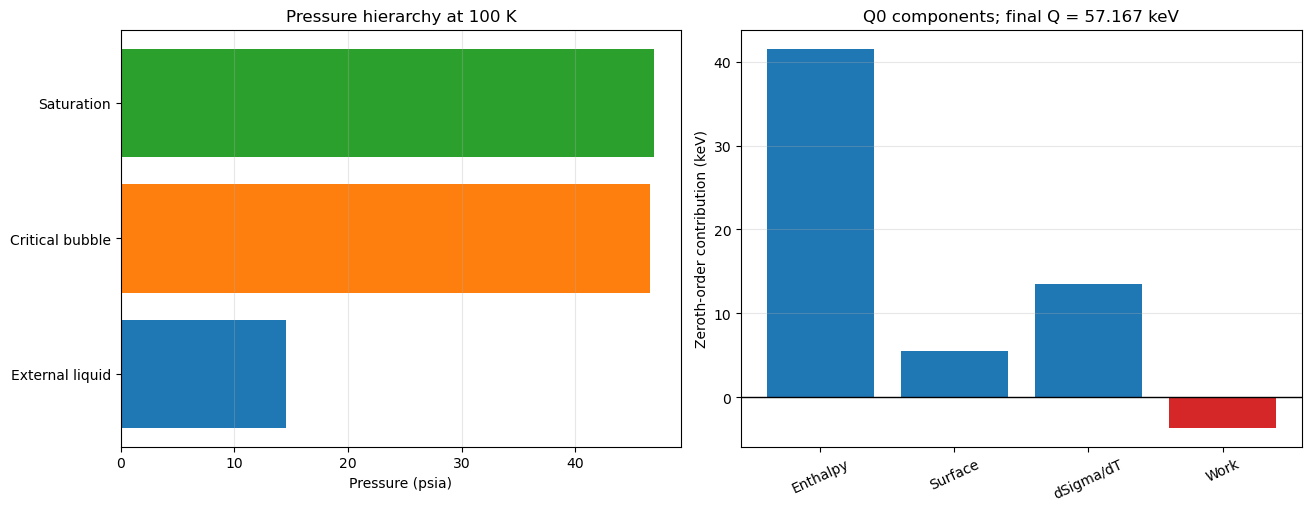

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

pressure_names = ["External liquid", "Critical bubble", "Saturation"]
pressure_values = [
    pressure_bar * PSIA_PER_BAR,
    seitz.Pbub,
    seitz.Pvap,
]
axes[0].barh(pressure_names, pressure_values, color=["tab:blue", "tab:orange", "tab:green"])
axes[0].set(
    xlabel="Pressure (psia)",
    title=f"Pressure hierarchy at {temperature_K:g} K",
)
axes[0].grid(axis="x", alpha=0.3)

component_names = ["Enthalpy", "Surface", "dSigma/dT", "Work"]
component_values = [seitz.Q0_h, seitz.Q0_s, seitz.Q0_ds, seitz.Q0_w]
colors = ["tab:red" if value < 0 else "tab:blue" for value in component_values]
axes[1].bar(component_names, component_values, color=colors)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(
    ylabel="Zeroth-order contribution (keV)",
    title=f"Q0 components; final Q = {seitz.Q:.3f} keV",
)
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.show()


In [6]:
assert seitz.errID is None
assert seitz.Q > 0
assert seitz.Rc > 0
assert seitz.Pvap > pressure_bar * PSIA_PER_BAR
assert seitz.Pbub > pressure_bar * PSIA_PER_BAR
assert abs(seitz.P_err) < 1e-6

print("REFPROP and SeitzModel validation passed.")


REFPROP and SeitzModel validation passed.
